<a href="https://colab.research.google.com/github/kilchinskiy/Hw.12.ipynb/blob/main/Hw_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Встановлення бібліотеки SpaCy
!pip install spacy

# Завантаження мовної моделі для англійської мови
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Імпорт бібліотек для NLP
import spacy
import nltk

# Імпорт інструментів NLTK
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# Імпорт пунктуації
from string import punctuation

# Імпорт функції для вибору найбільших елементів
from heapq import nlargest

In [3]:
# Завантаження необхідних ресурсів NLTK
# punkt — токенізатор речень
# punkt_tab — додаткові дані для токенізації
# stopwords — список стоп-слів

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# Завантаження мовної моделі SpaCy
nlp = spacy.load("en_core_web_sm")

In [5]:
# текст для створення summary

text = """
The Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering. Because it has achieved significance within the past fifty years, Criteria Consideration G applies. Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program to date; she was the third of five orbiters built by NASA. Unlike the Mercury, Gemini, and Apollo programs, the SSP’s emphasis was on cost effectiveness and reusability, and eventually the construction of a space station. Including her maiden voyage (launched August 30, 1984), Discovery flew to space thirty-nine times, more than any of the other four orbiters; she was also the first orbiter to fly twenty missions. She had the honor of being chosen as the Return to Flight vehicle after both the Challenger and Columbia accidents. Discovery was the first shuttle to fly with the redesigned SRBs, a result of the Challenger accident, and the first shuttle to fly with the Phase II and Block I SSME. Discovery also carried the Hubble Space Telescope to orbit and performed two of the five servicing missions to the observatory. She flew the first and last dedicated Department of Defense (DoD) missions, as well as the first unclassified defense-related mission. In addition, Discovery was vital to the construction of the International Space Station (ISS); she flew thirteen of the thirty-seven total missions flown to the station by a U.S. Space Shuttle. She was the first orbiter to dock to the ISS, and the first to perform an exchange of a resident crew. Under Criterion C, Discovery is significant as a feat of engineering. According to Wayne Hale, a flight director from Johnson Space Center, the Space Shuttle orbiter represents a “huge technological leap from expendable rockets and capsules to a reusable, winged, hypersonic, cargo-carrying spacecraft.” Although her base structure followed a conventional aircraft design, she used advanced materials that both minimized her weight for cargo-carrying purposes and featured low thermal expansion ratios, which provided a stable base for her Thermal Protection System (TPS) materials. The Space Shuttle orbiter also featured the first reusable TPS; all previous spaceflight vehicles had a single-use, ablative heat shield. Other notable engineering achievements of the orbiter included the first reusable orbital propulsion system, and the first two-fault-tolerant Integrated Avionics System. As Hale stated, the Space Shuttle remains “the largest, fastest, winged hypersonic aircraft in history,” having regularly flown at twenty-five times the speed of sound.
"""

In [6]:
# Додаємо символ нового рядка до пунктуації (як вказано в умовах)
punctuation = punctuation + '\n'

# Розбиття тексту на речення
sentence_tokens = sent_tokenize(text)

# Обробка тексту через SpaCy
doc = nlp(text)

# Завантаження списку стоп-слів
stop_words = set(stopwords.words("english"))

# Перегляд отриманих речень
sentence_tokens

['\nThe Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering.',
 'Because it has achieved significance within the past fifty years, Criteria Consideration G applies.',
 'Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program to date; she was the third of five orbiters built by NASA.',
 'Unlike the Mercury, Gemini, and Apollo programs, the SSP’s emphasis was on cost effectiveness and reusability, and eventually the construction of a space station.',
 'Including her maiden voyage (launched August 30, 1984), Discovery flew to space thirty-nine times, more than any of the other four orbiters; she was also the first orbiter 

In [7]:
# Створення словника для частоти слів
word_frequencies = {}

# Проходимо по кожному слову у тексті
for word in doc:

    # Перевіряємо, щоб слово не було стоп-словом або пунктуацією
    if word.text.lower() not in stop_words and word.text.lower() not in punctuation:

        # Якщо слово ще не в словнику — додаємо
        if word.text.lower() not in word_frequencies:
            word_frequencies[word.text.lower()] = 1

        # Якщо вже є — збільшуємо лічильник
        else:
            word_frequencies[word.text.lower()] += 1

# Виведення словника частот
word_frequencies

{'orbiter': 7,
 'discovery': 7,
 'ov-103': 1,
 'considered': 1,
 'eligible': 1,
 'listing': 1,
 'national': 1,
 'register': 1,
 'historic': 1,
 'places': 1,
 'nrhp': 1,
 'context': 1,
 'u.s.': 2,
 'space': 13,
 'shuttle': 8,
 'program': 3,
 '1969': 1,
 '2011': 1,
 'criterion': 4,
 'areas': 1,
 'exploration': 1,
 'transportation': 1,
 'c': 2,
 'area': 1,
 'engineering': 3,
 'achieved': 1,
 'significance': 1,
 'within': 1,
 'past': 1,
 'fifty': 1,
 'years': 1,
 'criteria': 1,
 'consideration': 1,
 'g': 1,
 'applies': 1,
 'significant': 2,
 'oldest': 1,
 'three': 1,
 'extant': 1,
 'vehicles': 2,
 'constructed': 1,
 'ssp': 2,
 'longest': 1,
 'running': 1,
 'american': 1,
 'date': 1,
 'third': 1,
 'five': 3,
 'orbiters': 2,
 'built': 1,
 'nasa': 1,
 'unlike': 1,
 'mercury': 1,
 'gemini': 1,
 'apollo': 1,
 'programs': 1,
 '’s': 1,
 'emphasis': 1,
 'cost': 1,
 'effectiveness': 1,
 'reusability': 1,
 'eventually': 1,
 'construction': 2,
 'station': 3,
 'including': 1,
 'maiden': 1,
 'voyage': 

In [8]:
# Знаходження максимальної частоти слова
max_frequency = max(word_frequencies.values())

# Нормалізація частоти (переведення значень у діапазон 0–1)
for word in word_frequencies.keys():
    word_frequencies[word] = word_frequencies[word] / max_frequency

# Перегляд нормалізованих значень
word_frequencies

{'orbiter': 0.5384615384615384,
 'discovery': 0.5384615384615384,
 'ov-103': 0.07692307692307693,
 'considered': 0.07692307692307693,
 'eligible': 0.07692307692307693,
 'listing': 0.07692307692307693,
 'national': 0.07692307692307693,
 'register': 0.07692307692307693,
 'historic': 0.07692307692307693,
 'places': 0.07692307692307693,
 'nrhp': 0.07692307692307693,
 'context': 0.07692307692307693,
 'u.s.': 0.15384615384615385,
 'space': 1.0,
 'shuttle': 0.6153846153846154,
 'program': 0.23076923076923078,
 '1969': 0.07692307692307693,
 '2011': 0.07692307692307693,
 'criterion': 0.3076923076923077,
 'areas': 0.07692307692307693,
 'exploration': 0.07692307692307693,
 'transportation': 0.07692307692307693,
 'c': 0.15384615384615385,
 'area': 0.07692307692307693,
 'engineering': 0.23076923076923078,
 'achieved': 0.07692307692307693,
 'significance': 0.07692307692307693,
 'within': 0.07692307692307693,
 'past': 0.07692307692307693,
 'fifty': 0.07692307692307693,
 'years': 0.07692307692307693,


In [9]:
# Створення словника для оцінки речень
sentence_scores = {}

# Проходимо по кожному реченню
for sent in sentence_tokens:

    # Розбиваємо речення на слова
    for word in word_tokenize(sent.lower()):

        # Якщо слово є у словнику частот
        if word in word_frequencies:

            # Якщо речення ще немає у словнику — додаємо
            if sent not in sentence_scores:
                sentence_scores[sent] = word_frequencies[word]

            # Якщо є — додаємо вагу слова
            else:
                sentence_scores[sent] += word_frequencies[word]

# Перегляд оцінок речень
sentence_scores

{'\nThe Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering.': 6.153846153846152,
 'Because it has achieved significance within the past fifty years, Criteria Consideration G applies.': 0.7692307692307692,
 'Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program to date; she was the third of five orbiters built by NASA.': 6.153846153846152,
 'Unlike the Mercury, Gemini, and Apollo programs, the SSP’s emphasis was on cost effectiveness and reusability, and eventually the construction of a space station.': 2.3076923076923075,
 'Including her maiden voyage (launched August 30, 1984), Discovery flew to space thirty-nine ti

In [10]:
# Визначення кількості речень для summary (30% від тексту)
select_length = int(len(sentence_tokens) * 0.3)

# Вибір найважливіших речень за допомогою heapq
summary_sentences = nlargest(select_length, sentence_scores, key=sentence_scores.get)

# Об'єднання речень у фінальний текст
summary = " ".join(summary_sentences)

# Виведення summary
print(summary)

According to Wayne Hale, a flight director from Johnson Space Center, the Space Shuttle orbiter represents a “huge technological leap from expendable rockets and capsules to a reusable, winged, hypersonic, cargo-carrying spacecraft.” Although her base structure followed a conventional aircraft design, she used advanced materials that both minimized her weight for cargo-carrying purposes and featured low thermal expansion ratios, which provided a stable base for her Thermal Protection System (TPS) materials. 
The Orbiter Discovery, OV-103, is considered eligible for listing in the National Register of Historic Places (NRHP) in the context of the U.S. Space Shuttle Program (1969-2011) under Criterion A in the areas of Space Exploration and Transportation and under Criterion C in the area of Engineering. Under Criterion A, Discovery is significant as the oldest of the three extant orbiter vehicles constructed for the Space Shuttle Program (SSP), the longest running American space program 

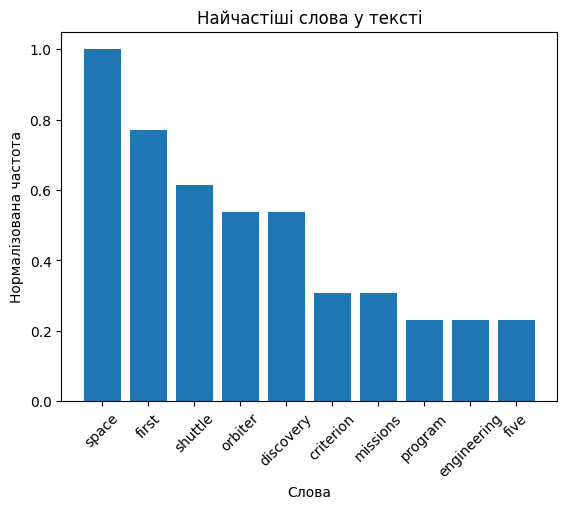

In [11]:
# Імпорт бібліотеки для побудови графіків
import matplotlib.pyplot as plt

# Вибираємо 10 найчастіших слів
top_words = nlargest(10, word_frequencies, key=word_frequencies.get)

# Отримуємо їх частоти
top_frequencies = [word_frequencies[word] for word in top_words]

# Побудова графіка
plt.figure()

# Побудова стовпчикового графіка
plt.bar(top_words, top_frequencies)

# Підписи графіка
plt.title("Найчастіші слова у тексті")
plt.xlabel("Слова")
plt.ylabel("Нормалізована частота")

# Поворот підписів слів для кращої читабельності
plt.xticks(rotation=45)

# Відображення графіка
plt.show()

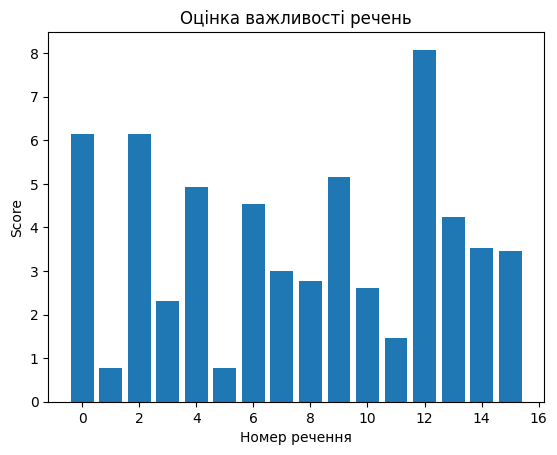

In [12]:
# Отримуємо речення та їх оцінки
sentences = list(sentence_scores.keys())
scores = list(sentence_scores.values())

# Побудова графіка
plt.figure()

plt.bar(range(len(scores)), scores)

# Підписи графіка
plt.title("Оцінка важливості речень")
plt.xlabel("Номер речення")
plt.ylabel("Score")

plt.show()

# У ході виконання роботи було використано бібліотеки SpaCy та NLTK для обробки природної мови та створення автоматичного текстового резюме.
# Було виконано:
# токенізацію тексту на слова та речення;
# видалення стоп-слів та пунктуації;
# підрахунок частоти слів;
# оцінювання важливості речень;
# автоматичне формування summary на основі найбільш значущих речень.
# Для візуалізації результатів було побудовано графіки, які показують частоту найважливіших слів та оцінку важливості речень.
# Таким чином, метод екстрактивного резюмування дозволяє автоматично виділяти ключову інформацію з тексту та значно спрощує аналіз великих текстових даних.